## Setup

In [ ]:
import os
import h5py
import glob
import math
import webdataset as wds
import pandas as pd
import numpy as np

from utils.constant import *
from utils.paths import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import balanced_accuracy_score

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import umap

In [21]:
RES_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RES_DIR, exist_ok=True)

In [22]:
IMG_VIS_DIR = 'img_vis'
os.makedirs(os.path.join(RES_DIR, IMG_VIS_DIR), exist_ok=True)

## Dataset

In [23]:
def make_dataloader(patterns, labels_to_ids, split, batch_size, transform):
    def is_selected_class(sample):
        return sample[1]["label"] in labels_to_ids

    dataset = (
        wds.WebDataset(patterns[split], shardshuffle=False)
        .decode("pil")
        .to_tuple("jpg", "json", "__url__", '__key__')
        .select(is_selected_class)
        .map_tuple(
            transform,
            lambda x: labels_to_ids[x["label"]],
            lambda url: url,
            lambda key: key,
        )
        .map(lambda sample: (sample[0], sample[1], f"{os.path.basename(sample[2])}#{sample[3]}"))
    )
    return DataLoader(dataset, batch_size=batch_size)

## Visualization of Adversarial Images and the Effects of Gaussian Smoothing Defense

In [24]:
def visualize_adv_images(images, adv_images45, adv_images40, adv_images35, save_path, max_images=16):
    """Visualize original/clean images and adversarial images generated at different PSNR targets."""
    n = min(images.shape[0], max_images)
    n_cols = 4

    fig, axes = plt.subplots(n, n_cols, figsize=(n_cols * 2, n * 2))
    if n == 1:
        axes = axes.reshape(1, -1)
    plt.subplots_adjust(hspace=0.08, wspace=0.05)
    col_titles = ["Original", "Adv (PSNR 45dB)", "Adv (PSNR 40dB)", "Adv (PSNR 35dB)"]

    def to_numpy_img(t):
        img = t.detach().cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        return np.clip(img, 0, 1)

    for row in range(n):
        imgs_row = [images[row], adv_images45[row], adv_images40[row], adv_images35[row]]
        for col, img_t in enumerate(imgs_row):
            ax = axes[row, col]
            ax.imshow(to_numpy_img(img_t))
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if row == 0:
                ax.set_title(col_titles[col], fontsize=11, pad=10)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

In [25]:
def visualize_adv_perturbation(image_original, adv45, adv40, adv35, save_path, scale_factor=20.0):
    """Visualize the magnitude of adversarial perturbations for different PSNR targets."""
    def _to_numpy(img):
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().numpy()
        else:
            img = np.copy(img)
        if img.ndim == 3 and img.shape[0] in [1, 3]:
            img = np.transpose(img, (1, 2, 0))
        return img.squeeze()

    img_orig = _to_numpy(image_original)
    adv_list = [
        ("Adv (PSNR 45dB)", _to_numpy(adv45)),
        ("Adv (PSNR 40dB)", _to_numpy(adv40)),
        ("Adv (PSNR 35dB)", _to_numpy(adv35)),
    ]

    fig, axes = plt.subplots(3, 3, figsize=(5, 5))
    for row_idx, (label, img_adv) in enumerate(adv_list):
        perturbation = np.abs(img_adv - img_orig)
        perturbation_scaled = np.clip(perturbation * scale_factor, 0, 1)

        axes[row_idx, 0].imshow(img_orig)
        axes[row_idx, 0].set_title("Original", fontsize=10)
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(img_adv)
        axes[row_idx, 1].set_title(label, fontsize=10)
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(perturbation_scaled)
        axes[row_idx, 2].set_title(f"Adv Perturbation", fontsize=10)
        axes[row_idx, 2].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [26]:
def visualize_defense_effects(image_clean, image_adv, save_path, sigmas=SIGMA):
    """Visualize the effect of Gaussian smoothing defense on clean and adversarial images."""

    n_cols = len(sigmas) + 1
    fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 2, 3))

    def to_numpy_img(t):
        img = t.detach().cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        return np.clip(img, 0, 1)

    def clean_ax(ax):
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    axes[0, 0].imshow(to_numpy_img(image_clean))
    axes[0, 0].set_title("No defense", fontsize=13)
    clean_ax(axes[0, 0])

    axes[1, 0].imshow(to_numpy_img(image_adv))
    clean_ax(axes[1, 0])

    for i, sigma in enumerate(sigmas):
        kernel_size = 2 * math.ceil(3 * sigma) + 1
        gaussian_filter = transforms.GaussianBlur(kernel_size=kernel_size, sigma=sigma)

        blurred_clean = gaussian_filter(image_clean)
        blurred_adv = gaussian_filter(image_adv)

        axes[0, i + 1].imshow(to_numpy_img(blurred_clean))
        axes[0, i + 1].set_title(f"σ={sigma}", fontsize=13)
        clean_ax(axes[0, i + 1])

        axes[1, i + 1].imshow(to_numpy_img(blurred_adv))
        clean_ax(axes[1, i + 1])

    axes[0, 0].set_ylabel("Original", fontsize=13, rotation=0, labelpad=25, ha='right', va='center')
    axes[1, 0].set_ylabel("Adversarial", fontsize=13, rotation=0, labelpad=25, ha='right', va='center')

    plt.subplots_adjust(wspace=0.05, hspace=0.1)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

In [27]:
model_name = 'uni_v1'
num_batch_to_vis = 4

base_transform = transforms.Compose([
        transforms.Resize(size=224, interpolation=transforms.InterpolationMode.BILINEAR, antialias=True),
        transforms.CenterCrop(size=(224, 224)),
        transforms.ToTensor()
    ])

loader = make_dataloader(patterns=PATTERNS, labels_to_ids=LABELS_TO_IDS, split='test', batch_size=16, transform=base_transform)
for i, (images, labels, names) in enumerate(loader):
    if i >= num_batch_to_vis:
        break

data = torch.load(get_adv_images_path(model_name, '45dB', 'test', num_batch_to_vis))
adv_images45 = data['adv_images']

data = torch.load(get_adv_images_path(model_name, '40dB', 'test', num_batch_to_vis))
adv_images40 = data['adv_images']

data = torch.load(get_adv_images_path(model_name, '35dB', 'test', num_batch_to_vis))
adv_images35 = data['adv_images']

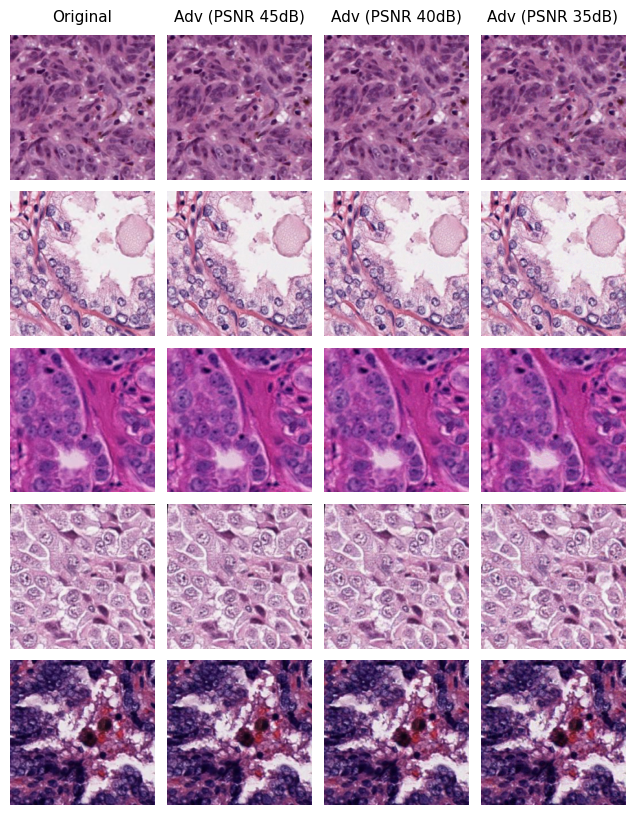

In [28]:
visualize_adv_images(images, adv_images45, adv_images40, adv_images35, os.path.join(RES_DIR, IMG_VIS_DIR, f'adv_img_{model_name}.png'), max_images=5)

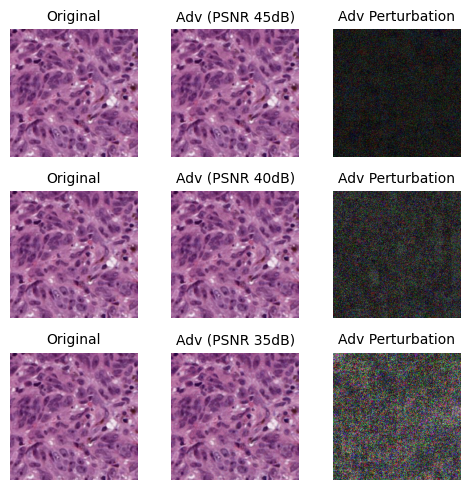

In [29]:
visualize_adv_perturbation(images[0], adv_images45[0], adv_images40[0], adv_images35[0], save_path=os.path.join(RES_DIR, IMG_VIS_DIR, f'adv_perturbation_{model_name}.png'), scale_factor=20.0)

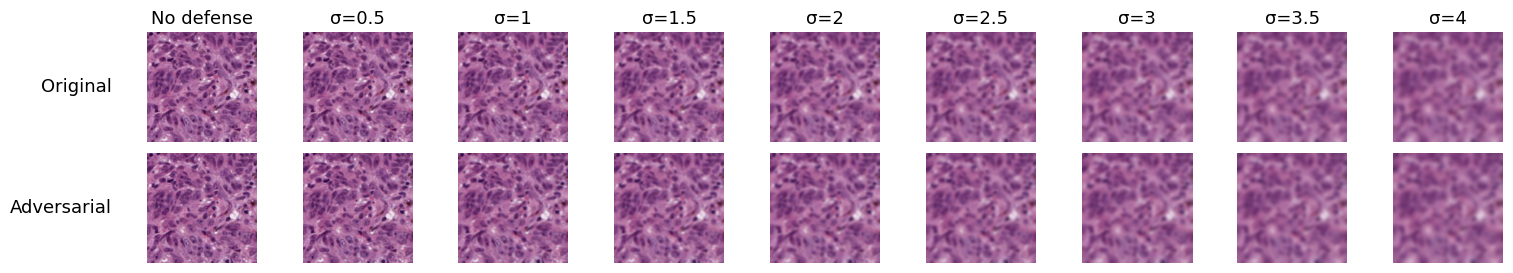

In [30]:
visualize_defense_effects(images[0], adv_images35[0], os.path.join(RES_DIR, IMG_VIS_DIR, f'defense_effects_{model_name}.png'), sigmas=SIGMA)